# Statistička analiza: UK Train Rides Dataset

Autor: Josip Pevec  
Alat: Python / Google Colab  
Dataset: `railway.csv`

## 1. Cilj analize

Cilj je analizirati cijene karata, status putovanja, kašnjenja, razloge kašnjenja i povezanost između ključnih varijabli. Analiza uključuje deskriptivnu statistiku, vizualizacije, korelacijsku analizu, t-test, ANOVA test i hi-kvadrat test.

## 2. Učitavanje biblioteka

In [ ]:
# Uvoz osnovnih Python biblioteka za rad s podacima i statistiku
# pandas -> rad s tabličnim podacima, slično Excel tablici
import pandas as pd

# numpy -> numerički izračuni i rad s nizovima podataka
import numpy as np

# matplotlib -> izrada grafova i vizualizacija
import matplotlib.pyplot as plt

# scipy.stats -> statistički testovi, npr. t-test, ANOVA, hi-kvadrat test
from scipy import stats

# Opcionalno, ako želiš ljepše grafove možeš koristiti seaborn biblioteku.
# U ovom notebooku glavni grafovi rade i bez seaborn-a.
# import seaborn as sns


## 3. Učitavanje CSV datoteke

`railway.csv`

In [ ]:
# Uvoz modula za ručni upload datoteka u Google Colab
from google.colab import files

# Ako railway.csv nije već u /content direktoriju, odkomentiraj sljedeću liniju
# i ručno učitaj CSV datoteku u Colab.
# uploaded = files.upload()

# Učitavanje CSV datoteke u pandas DataFrame.
# DataFrame je glavna tablica nad kojom radimo analizu.
df = pd.read_csv('/content/railway.csv')

# Prikaz prvih 5 redaka, kako bismo provjerili je li datoteka ispravno učitana.
df.head()


,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


## 4. Osnovni pregled podataka

In [ ]:
# Ispis dimenzija dataseta: broj redaka i broj stupaca.
print('Broj redaka i stupaca:', df.shape)

# Prikaz prvih nekoliko redaka tablice.
display(df.head())

# Pregled tipova podataka, broja nepraznih vrijednosti i memorijske potrošnje.
display(df.info())

# Deskriptivna statistika za sve stupce.
# include='all' uključuje i numeričke i tekstualne/kategorijske stupce.
display(df.describe(include='all'))


Broj redaka i stupaca: (31653, 18)


,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

None

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
count,31653,31653,31653,31653,31653,10735,31653,31653,31653.000000,31653,31653,31653,31653,31653,29773,31653,4172,31653
unique,31653,128,24351,2,3,3,2,3,NaN,12,32,121,96,203,623,3,8,2
top,1d5d89a2-bde5-410f-8f91,2024-02-02,17:22:17,Online,Credit Card,Adult,Standard,Advance,NaN,Manchester Piccadilly,Birmingham New Street,2024-03-09,18:45:00,19:05:00,19:05:00,On Time,Weather,No
freq,1,513,6,18521,19136,4846,28595,17561,NaN,5650,7742,313,2598,1069,1013,27481,995,30535
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.439200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Provjera nedostajućih vrijednosti

In [ ]:
# Provjera nedostajućih vrijednosti po svakom stupcu.
# isnull() vraća True gdje vrijednost nedostaje, a sum() zbraja takve slučajeve.
missing = df.isnull().sum().sort_values(ascending=False)

# Prikazujemo samo stupce koji imaju barem jednu nedostajuću vrijednost.
missing[missing > 0]


,0
Reason for Delay,27481
Railcard,20918
Actual Arrival Time,1880


## 6. Priprema izvedenih varijabli

Iz vremena putovanja računamo planirano trajanje, stvarno kašnjenje u minutama i broj dana između kupnje karte i putovanja.

In [ ]:
# Pretvaranje datumskih stupaca iz teksta u pravi datetime format.
# errors='coerce' znači da će neispravne vrijednosti postati NaT, tj. prazni datum.
for c in ['Date of Purchase', 'Date of Journey']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# Kreiranje planiranog vremena polaska kombiniranjem datuma putovanja i vremena polaska.
df['scheduled_departure'] = pd.to_datetime(
    df['Date of Journey'].dt.strftime('%Y-%m-%d') + ' ' + df['Departure Time'],
    errors='coerce'
)

# Kreiranje planiranog vremena dolaska kombiniranjem datuma putovanja i vremena dolaska.
df['scheduled_arrival'] = pd.to_datetime(
    df['Date of Journey'].dt.strftime('%Y-%m-%d') + ' ' + df['Arrival Time'],
    errors='coerce'
)

# Ako je dolazak vremenski manji od polaska, znači da je putovanje prešlo preko ponoći.
# U tom slučaju dodajemo jedan dan na vrijeme dolaska.
df.loc[df['scheduled_arrival'] < df['scheduled_departure'], 'scheduled_arrival'] += pd.Timedelta(days=1)

# Kreiranje stvarnog vremena dolaska na temelju stupca Actual Arrival Time.
df['actual_arrival'] = pd.to_datetime(
    df['Date of Journey'].dt.strftime('%Y-%m-%d') + ' ' + df['Actual Arrival Time'],
    errors='coerce'
)

# I za stvarni dolazak korigiramo slučajeve kada putovanje prelazi preko ponoći.
df.loc[df['actual_arrival'] < df['scheduled_departure'], 'actual_arrival'] += pd.Timedelta(days=1)

# Izračun kašnjenja u minutama: stvarni dolazak minus planirani dolazak.
df['delay_minutes'] = (df['actual_arrival'] - df['scheduled_arrival']).dt.total_seconds() / 60

# Izračun planiranog trajanja putovanja u minutama.
df['planned_duration_minutes'] = (df['scheduled_arrival'] - df['scheduled_departure']).dt.total_seconds() / 60

# Kreiranje točnog vremena kupnje karte kombiniranjem datuma i vremena kupnje.
df['purchase_dt'] = pd.to_datetime(
    df['Date of Purchase'].dt.strftime('%Y-%m-%d') + ' ' + df['Time of Purchase'],
    errors='coerce'
)

# Izračun koliko je dana prije putovanja kupljena karta.
df['days_before_journey'] = (df['scheduled_departure'] - df['purchase_dt']).dt.total_seconds() / 86400

# Čišćenje stupca Railcard: ako nema vrijednosti, označavamo kao 'No railcard'.
df['Railcard_clean'] = df['Railcard'].fillna('No railcard')

# Standardizacija naziva razloga kašnjenja i popunjavanje praznih vrijednosti.
df['Reason_clean'] = df['Reason for Delay'].replace({
    'Signal failure': 'Signal Failure',
    'Weather Conditions': 'Weather',
    'Staff Shortage': 'Staffing'
}).fillna('No delay / no reason')

# Kreiranje novog stupca Route koji spaja polaznu i odredišnu stanicu.
df['Route'] = df['Departure Station'] + ' -> ' + df['Arrival Destination']

# Provjera novokreiranih numeričkih stupaca pomoću deskriptivne statistike.
df[['Price', 'delay_minutes', 'planned_duration_minutes', 'days_before_journey']].describe()


,Price,delay_minutes,planned_duration_minutes,days_before_journey
count,31653.000000,29773.000000,31653.000000,31653.000000
mean,23.439200,3.249689,71.154235,1.659474
std,29.997628,14.770539,36.330811,3.838401
min,1.000000,0.000000,15.000000,0.010440
25%,5.000000,0.000000,30.000000,0.057940
50%,11.000000,0.000000,80.000000,0.927905
75%,35.000000,0.000000,90.000000,0.935023
max,267.000000,180.000000,270.000000,28.651748


## 7. Deskriptivna statistika

In [ ]:
# Izračun osnovnih deskriptivnih mjera za cijenu karte.
# Prosjek govori kolika je prosječna cijena, a medijan tipičnu srednju vrijednost.
print('Prosječna cijena:', round(df['Price'].mean(), 2))
print('Medijan cijene:', round(df['Price'].median(), 2))
print('Standardna devijacija cijene:', round(df['Price'].std(), 2))
print('Minimalna cijena:', df['Price'].min())
print('Maksimalna cijena:', df['Price'].max())

# Broj putovanja prema statusu, npr. On Time, Delayed ili Cancelled.
display(df['Journey Status'].value_counts())

# Isti prikaz, ali u postocima radi lakše interpretacije.
display(df['Journey Status'].value_counts(normalize=True).mul(100).round(2))


Prosječna cijena: 23.44
Medijan cijene: 11.0
Standardna devijacija cijene: 30.0
Minimalna cijena: 1
Maksimalna cijena: 267


,count
Journey Status,
On Time,27481
Delayed,2292
Cancelled,1880


,proportion
Journey Status,
On Time,86.82
Delayed,7.24
Cancelled,5.94


## 8. Naprednije vizualizacije

In [ ]:
# Histogram prikazuje distribuciju cijena karata.
# bins=40 znači da raspon cijena dijelimo u 40 intervala.
plt.figure(figsize=(10,5))
plt.hist(df['Price'], bins=40)
plt.title('Distribucija cijena karata')
plt.xlabel('Cijena')
plt.ylabel('Broj transakcija')
plt.show()


In [ ]:
# Bar chart prikazuje koliko ima putovanja po svakom statusu.
# Ovaj graf je dobar za brzo razumijevanje udjela kašnjenja i otkazivanja.
plt.figure(figsize=(7,4))
df['Journey Status'].value_counts().plot(kind='bar')
plt.title('Status putovanja')
plt.xlabel('Status')
plt.ylabel('Broj putovanja')
plt.show()


In [ ]:
# Boxplot uspoređuje cijene karata po klasama.
# Koristan je jer prikazuje medijan, raspršenost i outliere.
plt.figure(figsize=(7,5))
df.boxplot(column='Price', by='Ticket Class')
plt.title('Cijene karata po klasi')
plt.suptitle('')  # uklanja automatski dodatni naslov koji pandas generira
plt.xlabel('Klasa karte')
plt.ylabel('Cijena')
plt.show()


In [ ]:
# Prikaz najčešćih razloga kašnjenja.
# Izbacujemo vrijednost 'No delay / no reason' jer nas ovdje zanimaju stvarni razlozi kašnjenja.
plt.figure(figsize=(10,5))
df['Reason_clean'].value_counts().drop('No delay / no reason', errors='ignore').plot(kind='bar')
plt.title('Razlozi kašnjenja')
plt.xlabel('Razlog')
plt.ylabel('Broj')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# Grupiranje podataka po ruti.
# Za svaku rutu računamo broj vožnji, prosječnu cijenu i stopu kašnjenja.
route_stats = df.groupby('Route').agg(
    broj_voznji=('Route', 'size'),
    prosjecna_cijena=('Price', 'mean'),
    stopa_kasnjenja=('Journey Status', lambda s: (s == 'Delayed').mean() * 100)
).sort_values('broj_voznji', ascending=False)

# Prikaz 10 najčešćih ruta u datasetu.
display(route_stats.head(10))

# Horizontalni bar chart za stopu kašnjenja na 10 najčešćih ruta.
plt.figure(figsize=(10,5))
route_stats.head(10)['stopa_kasnjenja'].sort_values().plot(kind='barh')
plt.title('Stopa kašnjenja za 10 najčešćih ruta')
plt.xlabel('Udio kašnjenja (%)')
plt.show()


## 9. Korelacijska analiza

,Price,delay_minutes,planned_duration_minutes,days_before_journey
Price,1.000000,0.164244,0.632378,-0.077910
delay_minutes,0.164244,1.000000,0.065358,-0.006435
planned_duration_minutes,0.632378,0.065358,1.000000,0.009293
days_before_journey,-0.077910,-0.006435,0.009293,1.000000


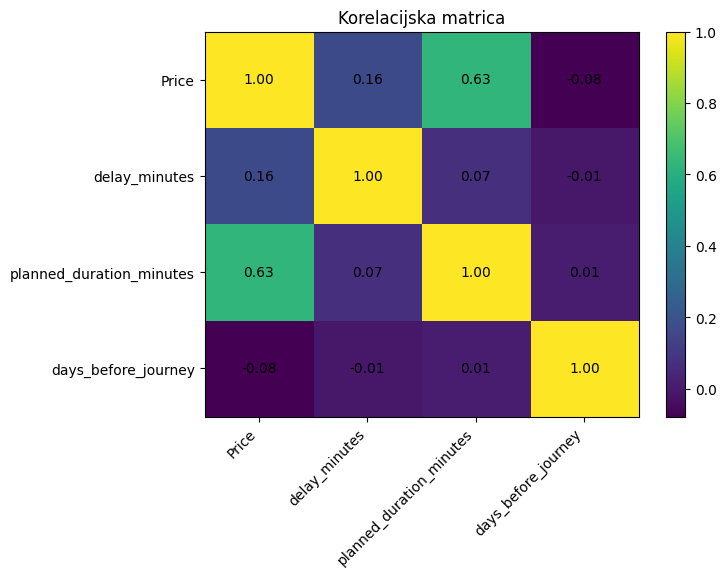

In [ ]:
# Korelacijska analiza između numeričkih varijabli.
# Korelacija se kreće od -1 do +1.
# Vrijednosti blizu +1 znače pozitivnu povezanost, blizu -1 negativnu, a oko 0 slabu povezanost.
corr = df[['Price', 'delay_minutes', 'planned_duration_minutes', 'days_before_journey']].corr()
display(corr)

# Ručna izrada heatmapa korelacijske matrice pomoću matplotliba.
plt.figure(figsize=(7,5))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)

# Upisujemo vrijednosti korelacije direktno u polja heatmapa.
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Korelacijska matrica')
plt.show()


## 10. T-test: Standard vs First Class

Hipoteze:

- H0: nema statistički značajne razlike u prosječnoj cijeni između Standard i First Class karata.
- H1: postoji statistički značajna razlika u prosječnoj cijeni.

In [ ]:
# T-test koristimo kada uspoređujemo prosjek dvije nezavisne grupe.
# Ovdje uspoređujemo cijene karata između Standard i First Class klase.
standard = df[df['Ticket Class'] == 'Standard']['Price']
first = df[df['Ticket Class'] == 'First Class']['Price']

# Welchov t-test: equal_var=False jer ne pretpostavljamo da grupe imaju jednaku varijancu.
t_result = stats.ttest_ind(standard, first, equal_var=False)
print(t_result)

# Interpretacija p-vrijednosti.
# Ako je p < 0.05, razlika se smatra statistički značajnom.
if t_result.pvalue < 0.05:
    print('Zaključak: odbacujemo H0 - postoji statistički značajna razlika u cijeni.')
else:
    print('Zaključak: ne odbacujemo H0 - nema dovoljno dokaza za razliku u cijeni.')


TtestResult(statistic=np.float64(-37.0236221484484), pvalue=np.float64(7.853960089226562e-252), df=np.float64(3349.5063227449004))
Zaključak: odbacujemo H0 - postoji statistički značajna razlika u cijeni.


## 11. ANOVA test: cijena prema tipu karte

Hipoteze:

- H0: prosječne cijene za različite tipove karata su jednake.
- H1: barem jedan tip karte ima različitu prosječnu cijenu.

In [ ]:
# ANOVA test koristimo kada uspoređujemo prosjeke više od dvije grupe.
# Ovdje uspoređujemo cijene karata prema tipu karte.
groups = [g['Price'].values for _, g in df.groupby('Ticket Type')]

# Jednofaktorska ANOVA provjerava postoji li barem jedna grupa čiji se prosjek razlikuje.
anova_result = stats.f_oneway(*groups)
print(anova_result)

# Interpretacija p-vrijednosti.
if anova_result.pvalue < 0.05:
    print('Zaključak: odbacujemo H0 - tip karte je povezan s razlikama u cijeni.')
else:
    print('Zaključak: ne odbacujemo H0.')

# Dodatna tablica s brojem zapisa, prosjekom, medijanom i standardnom devijacijom po tipu karte.
display(df.groupby('Ticket Type')['Price'].agg(['count', 'mean', 'median', 'std']).round(2))


F_onewayResult(statistic=np.float64(1169.5573241407785), pvalue=np.float64(0.0))
Zaključak: odbacujemo H0 - tip karte je povezan s razlikama u cijeni.


,count,mean,median,std
Ticket Type,,,,
Advance,17561,17.61,8.0,20.98
Anytime,5340,39.20,17.0,44.55
Off-Peak,8752,25.52,12.0,30.61


## 12. Hi-kvadrat test: status putovanja i zahtjev za povrat

Hipoteze:

- H0: status putovanja i zahtjev za povrat su nezavisni.
- H1: postoji povezanost između statusa putovanja i zahtjeva za povrat.

In [ ]:
# Hi-kvadrat test koristimo za dvije kategorijske varijable.
# Ovdje provjeravamo postoji li povezanost između statusa putovanja i zahtjeva za povrat novca.
refund_tab = pd.crosstab(df['Journey Status'], df['Refund Request'])
display(refund_tab)

# Izračun hi-kvadrat testa nezavisnosti.
chi2, p, dof, expected = stats.chi2_contingency(refund_tab)
print('Chi2:', chi2)
print('p-value:', p)

# Ako je p < 0.05, zaključujemo da varijable nisu nezavisne.
if p < 0.05:
    print('Zaključak: odbacujemo H0 - status putovanja i refund request nisu nezavisni.')
else:
    print('Zaključak: ne odbacujemo H0.')


Refund Request,No,Yes
Journey Status,,
Cancelled,1308,572
Delayed,1746,546
On Time,27481,0


Chi2: 7766.091130699457
p-value: 0.0
Zaključak: odbacujemo H0 - status putovanja i refund request nisu nezavisni.


## 13. Automatsko generiranje PDF izvještaja iz Pythona

Ova ćelija generira jednostavan PDF izvještaj direktno iz Colaba.

In [ ]:
# Instalacija reportlab biblioteke za generiranje PDF izvještaja iz Colaba.
# Znak ! znači da se naredba izvršava kao terminalska naredba, a ne kao Python kod.
!pip -q install reportlab

# Uvoz potrebnih dijelova reportlab biblioteke.
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

# Putanja na koju će se spremiti PDF izvještaj u Colabu.
pdf_path = '/content/uk_train_rides_izvjestaj.pdf'

# Kreiranje PDF dokumenta.
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

# Dodavanje naslova i osnovnih informacija u PDF.
story.append(Paragraph('Statistička analiza: UK Train Rides Dataset', styles['Title']))
story.append(Spacer(1, 12))
story.append(Paragraph(f'Broj zapisa: {len(df)}; broj stupaca: {df.shape[1]}', styles['Normal']))
story.append(Paragraph(f'Prosječna cijena karte: {df["Price"].mean():.2f}', styles['Normal']))
story.append(Paragraph(f'Medijan cijene: {df["Price"].median():.2f}', styles['Normal']))
story.append(Paragraph(f'Udio putovanja na vrijeme: {(df["Journey Status"].eq("On Time").mean()*100):.2f}%', styles['Normal']))
story.append(Spacer(1, 12))

# Tablica sa sažetkom najvažnijih statističkih mjera.
summary_data = [['Mjera', 'Vrijednost'],
                ['Prosječna cijena', f'{df["Price"].mean():.2f}'],
                ['Medijan cijene', f'{df["Price"].median():.2f}'],
                ['Std. devijacija cijene', f'{df["Price"].std():.2f}'],
                ['Prosječno kašnjenje odgođenih vlakova', f'{df.loc[df["Journey Status"].eq("Delayed"), "delay_minutes"].mean():.2f} min']]

# Formatiranje tablice u PDF-u.
table = Table(summary_data)
table.setStyle(TableStyle([('BACKGROUND', (0, 0), (-1, 0), colors.lightgrey),
                           ('GRID', (0, 0), (-1, -1), 0.5, colors.grey)]))
story.append(table)
story.append(Spacer(1, 12))

# Kratki završni zaključak izvještaja.
story.append(Paragraph('Zaključak: većina putovanja je na vrijeme, First Class karte su prosječno skuplje, a tip karte statistički značajno utječe na cijenu.', styles['Normal']))

# Generiranje PDF dokumenta.
doc.build(story)
print('PDF kreiran:', pdf_path)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.8 MB/s eta 0:00:00
PDF kreiran: /content/uk_train_rides_izvjestaj.pdf


## 14. Zaključak

Analiza pokazuje da je većina putovanja u datasetu evidentirana kao `On Time`. Prosječna cijena karte iznosi oko 23.44, dok je medijan znatno niži, što ukazuje na asimetričnu distribuciju i postojanje skupljih karata. First Class karte su očekivano skuplje od Standard karata, što potvrđuje i t-test. ANOVA test pokazuje da postoje statistički značajne razlike u cijenama između tipova karata. Hi-kvadrat test pokazuje povezanost između statusa putovanja i zahtjeva za povrat novca.